In [29]:
from importlib import reload
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

import data_import
data_import = reload(data_import)
from data_import import *

import data_management
data_management = reload(data_management)
from data_management import *

import features
features = reload(features)
from features import *

import helpers
helpers = reload(helpers)
from helpers import *

import gating
gating = reload(gating)
from gating import *

import backtest_engine
backtest_engine = reload(backtest_engine)
from backtest_engine import *

import validation
validation = reload(validation)
from validation import *

import backtest_prep
backtest_prep = reload(backtest_prep)
from backtest_prep import build_strategy_specs, compile_backtest_payload

import entry_analysis
entry_analysis = reload(entry_analysis)
from entry_analysis import *

from binance import AsyncClient

import strategies
strategies = reload(strategies)
from strategies import *

import time

In [ ]:

# frames = {"1daily":"1d", "4hourly": "4h"}
# dict_of_pairs = {pair: {"dict_of_frames":{frame: None for frame in frames}, "dict_of_levels": None} for pair in target_pairs}

In [ ]:
# try:
#     await client.close_connection()
# except:
#     pass

# client = await AsyncClient.create(requests_params={"timeout":360})
# tokens = pd.read_csv("references/binance_usdt_tokens.csv")

# len(tokens)


225

In [ ]:
# tokens = (await get_spot_usdt_pairs(client))[:-1]

In [ ]:
# start = "01-11-2000"
# end = "01-11-2027"

# target_pairs = tokens["option_symbol"].to_list()
# print(len(target_pairs))
# print(target_pairs[:5])

# frames = {"1daily":"1d", "4hourly": "4h"}
# dict_of_pairs_ori = {pair: {"dict_of_frames":{frame: None for frame in frames}} for pair in target_pairs}
# await new_update_frames(client, dict_of_pairs_ori, start=start, end=end, batch_length= 10, target_pairs=target_pairs, frames = frames, sanitize=False, limit=None, raw=True)


In [61]:
data_set = "validation"
execution_frame = "4hourly"

In [59]:
await update_dataset_to_latest(data_set)

validation: 450 stale (pair, frame) entries; downloading...
stored updated raw -> data/validation/raw.pickle
prepared: incremental tail (500 warmup bars)
stored prepared -> data/validation/prepared.pickle


In [49]:
dict_of_pairs_ori = read_pickle_object(f"data/{data_set}/raw")
pair = "BTCUSDT"
frame_df = dict_of_pairs_ori[pair]["dict_of_frames"]["4hourly"].copy()

frame_df.iloc[[0,-1]]["open_time"]

# === Cadence sanitization (before prepare_df so indicators are computed on clean bars) ===
# dict_of_pairs_ori = backtest_prep.sanitize_dataset_bar_cadence(
#     dict_of_pairs_ori,
#     min_spacing_ratio=0.9,
# )
# print(f"✓ Cadence-sanitized raw frames for {len(dict_of_pairs_ori)} pairs")

0      2026-01-21 00:00:00
1395   2026-09-10 12:00:00
Name: open_time, dtype: datetime64[ns]

In [ ]:
# store_pickle_object(f"data/{data_set}/raw", dict_of_pairs_ori)


True

In [36]:
# current_slippage_df = pd.DataFrame([await binance_slippage_capacity(client,pair,0.001,10000) for pair in dict_of_pairs_ori])
# current_slippage_array = current_slippage_df.set_index("pair")[["maximum_buy", "maximum_sell_quantity"]].to_numpy()


In [50]:
for pair in dict_of_pairs_ori:
    for frame in dict_of_pairs_ori[pair]['dict_of_frames']:

        frame_df = dict_of_pairs_ori[pair]['dict_of_frames'][frame]
        frame_df = prepare_df(frame_df)
        

        # frame_df = attach_trend_lines(frame_df, distance=3, window_peaks=4, 
        #                               margin=1.0, break_margin=0.0, spread_col="short_spread",)

        dict_of_pairs_ori[pair]['dict_of_frames'][frame] = frame_df

        if frame == "4hourly":
            frame_df = dict_of_pairs_ori[pair]['dict_of_frames'][frame]
            time_col = "open_time" if "open_time" in frame_df.columns else None
            if time_col is not None:
                time_index = pd.to_datetime(frame_df[time_col], errors="coerce")
                time_series = pd.Series(time_index, index=frame_df.index)
                open_series = pd.to_numeric(frame_df["open"], errors="coerce")

                year_key = time_series.dt.to_period("Y")
                month_key = time_series.dt.to_period("M")
                week_key = time_series.dt.to_period("W-SUN")  # Weeks start on Monday.

                frame_df["yearly_open"] = open_series.groupby(year_key).transform("first")
                frame_df["monthly_open"] = open_series.groupby(month_key).transform("first")
                frame_df["weekly_open"] = open_series.groupby(week_key).transform("first")

            dict_of_pairs_ori[pair]['dict_of_frames'][frame] = frame_df

        frame_df["rsi_slope"] = frame_df["rsi"].rolling(6).apply(get_simple_slope_2, raw=True)
        
dict_of_pairs_ori = attach_trend_lines_to_dataset(
    dict_of_pairs_ori,
    frames=["4hourly", "1daily"],  # which frames to annotate
    distance=3,                    # min bars between swing points (== confirmation lag)
    window_peaks=4,                # recent swings the line must loosely contain
    margin=1.0,                    # pierce tolerance in short_spread units
    break_margin=0.0,              # close-vs-line break tolerance in short_spread units
    spread_col="short_spread",
)

In [51]:
# === STEP 1: Apply features and basic gating (independent of execution frame) ===
# This prepares SQN, daily gate, and 4H structure at each pair
# These are computed once and reused regardless of execution_frame choice

print("Attaching SQN regime signals...")
dict_of_pairs_ori = attach_sqn_to_dataset(dict_of_pairs_ori)

print("Computing 4H structure...")
dict_of_pairs_ori = compute_4h_structure_for_dataset(
    dict_of_pairs_ori,
    ema_fast_period=25,
    ema_mid_period=50,
    ema_slow_period=200,
    slope_lookback=5
)


print("✓ Features computed (SQN, structure_ok)")
print(f"✓ Pairs ready: {len(dict_of_pairs_ori)}")

Attaching SQN regime signals...
Computing 4H structure...
✓ Features computed (SQN, structure_ok)
✓ Pairs ready: 225


In [7]:
# === STEP 1b: Choose execution frame ===
# This setting determines whether you'll trade on 1H or 4H bars
# Gating (1D) remains fixed. Structure (4H) remains fixed.
# Only the execution frame changes.

frame_list = ["1daily", "4hourly"]

execution_frame = "4hourly"  # or "4hourly"




print(f"Execution frame selected: {execution_frame}")
print(f"  - Gating stays on: 1daily")
print(f"  - Structure stays on: 4hourly")

Execution frame selected: 4hourly
  - Gating stays on: 1daily
  - Structure stays on: 4hourly


In [53]:
columns_for_merge = ["ma25", "ma50", "ma100", "ma200", "ema25", "ema50", "ema100", "ema200", "rsi", 'rsi_slope','max',
       'min', 'boll_upper', 'boll_mid', 'boll_lower']

columns_for_merge += ["upper_trend", "lower_trend"]
# columns_for_merge += [f"slope_{col}" for col in columns_for_merge]

for pair in dict_of_pairs_ori:

    for i in range(0,frame_list.index(execution_frame)):
        
        frame = frame_list[i]

        target = dict_of_pairs_ori[pair]['dict_of_frames'][execution_frame]
        source = dict_of_pairs_ori[pair]['dict_of_frames'][frame][columns_for_merge + ["close_time"]]

        dict_of_pairs_ori[pair]['dict_of_frames'][execution_frame] = pd.merge_asof(
            target.sort_values("close_time"),
            source.sort_values("close_time"),
            left_on="close_time",
            right_on="close_time",
            direction="backward",
            suffixes=[f"", f"_{frame}"]
        )
    

cols_for_retest = ['ma50',
 'boll_lower',
 'ema50',
 'ma200',
 'boll_mid_1daily',
 'ema100',
 'ma100',
 'ema200',
 'ema25_1daily', 'prev_low', "min", "ema25",
 "yearly_open", "monthly_open", "weekly_open", "nearest_support"]

cols_for_retest += ["lower_trend", "lower_trend_1daily"]

cols_for_break = [
                  "max","boll_upper", "boll_upper_1daily",
                  "ema100", "ema200", "ma100", "ma200",
                  "ema100_1daily", "ema200_1daily", "ma100_1daily", "ma200_1daily", "prev_high",
                  "yearly_open", "monthly_open", "weekly_open", "nearest_resistance"
                  ]

cols_for_break += ["upper_trend", "upper_trend_1daily"]

cols_to_prepare = cols_for_retest + cols_for_break

for pair in dict_of_pairs_ori:
    frame_df = dict_of_pairs_ori[pair]['dict_of_frames'][execution_frame]
    frame_df = add_hh_ll_columns(frame_df)

    frame_df = populate_historical_levels_fast(
        ohlc_df=frame_df,
        levels_reactions_limit=12,
        lookback_bars=None,   # or e.g. 6*90 for last 90 days on 4h bars
        price_col="close",
        skip_rows = 6*14
    )

    for col in list(set(cols_to_prepare)):

        retest_dict = level_test_buys_with_last_broken(frame_df, [col], confirm_breaks=False, confirm_tests=False)
        retest_frame = pd.DataFrame(retest_dict)

        rename_dict = {prop: f"{col}_{prop}" for prop in retest_dict}
        retest_frame.rename(columns=rename_dict, inplace=True)

        frame_df = pd.concat([frame_df, retest_frame], axis=1)

    frame_df["rolling_max"] = frame_df["close"].rolling(6*7).max()
    frame_df["rolling_min"] = frame_df["close"].rolling(6*7).min()
    frame_df["rolling_gain"] = frame_df["rolling_max"] / frame_df["rolling_min"]
    
    frame_df["obv"] = talib.OBV(frame_df["close"], frame_df["volume"] )



    frame_df = get_common_aux_columns(frame_df, rs_boost_weight=0.5, rs_boost_regime_conditional=True)
    
    dict_of_pairs_ori[pair]['dict_of_frames'][execution_frame] = frame_df

In [ ]:
# RS boost applied here (overrides the weight=0 call in the prep cell).
# rs_boost_regime_conditional=True scales the boost by BTC regime strength
# (btc_sqn_90_pct): full boost in strong regimes, ~0 in weak regimes.
# for pair in dict_of_pairs_ori:
#     frame_df = dict_of_pairs_ori[pair]['dict_of_frames'][execution_frame]
    # frame_df = get_common_aux_columns(frame_df, rs_boost_weight=0.5, rs_boost_regime_conditional=True)

    # frame_df["short_spread"] = talib.MA(frame_df.high-frame_df.low, 6*14)
    # dict_of_pairs_ori[pair]['dict_of_frames'][execution_frame] = frame_df

In [62]:
# store_pickle_object(f"data/{data_set}/prepared", dict_of_pairs_ori)
dict_of_pairs_ori = read_pickle_object(f"data/{data_set}/prepared")


pair = "BTCUSDT"
frame_df = dict_of_pairs_ori[pair]["dict_of_frames"]["4hourly"].copy()

frame_df.iloc[[0,-1]]["open_time"]


0      2025-11-01 00:00:00
1894   2026-09-12 16:00:00
Name: open_time, dtype: datetime64[ns]

In [63]:
# === STEP 2: Prepare execution frame dataset ===
# This configures gating (1D) + structure (4H) + execution frame (1H or 4H)
# Daily gating: btc_risk_on, pair_tradable, allowed_daily
# 4H structure: structure_ok
# Result: allowed_to_trade gate on execution_frame

# Toggle adaptive (rolling 252d percentile) vs fixed-threshold SQN gates.
# True = rolling percentile (recommended, adapts to market history);
# False = legacy fixed absolute SQN thresholds (for A/B comparison).
use_percentile = False

# Soft/adaptive BTC risk gate with hysteresis: stays risk-on through brief
# dips in a strong regime (expansion), flips off only on sustained weakness
# (slow market). True = recommended; False = plain threshold gate.
adaptive_btc_risk = False

# Recovery floor on the exposure multiplier: once BTC price is back above its
# 50d MA, the multiplier is floored at recovery_floor even while the slow SQN
# percentile is still catching up — so the bot participates in recoveries
# instead of staying flat through the whole bounce-back. False = no floor.
use_recovery_floor = False
recovery_ma_period = 50
recovery_floor = 0.35

# === BTC 4h DRIFT FILTER (NEW, backtest-only) ===
# Soft exposure multiplier driven by BTC 4h drift (rolling sum of per-bar
# returns over btc_drift_bars), softened by a hysteresis state machine
# (mirror of adaptive_btc_risk). It scales ENTRY SIZE by
# btc_drift_exposure_multiplier (1.0 when drift_ok, else btc_drift_floor).
# Entries are never blocked — only sized down in weak drift ("does not gate
# too much"). Set use_btc_drift_multiplier=False to revert to baseline (no
# drift column attached). Engine must set exposure_multiplier_col to
# "btc_drift_exposure_multiplier" (STEP 7) for it to take effect.
use_btc_drift_multiplier = True
btc_drift_bars = 12
btc_drift_floor = 0.4
btc_drift_turn_on_threshold = 0.01
btc_drift_turn_off_threshold = -0.01
btc_drift_turn_on_bars = 2
btc_drift_turn_off_bars = 2

dict_of_pairs_ori = prepare_execution_frame_dataset(
    dict_of_pairs=dict_of_pairs_ori,
    execution_frame=execution_frame,
    btc_pair="BTCUSDT",
    structure_col="structure_ok",
    use_percentile=use_percentile,
    adaptive_btc_risk=adaptive_btc_risk,
    use_recovery_floor=use_recovery_floor,
    recovery_ma_period=recovery_ma_period,
    recovery_floor=recovery_floor,
    use_btc_drift_multiplier=use_btc_drift_multiplier,
    btc_drift_bars=btc_drift_bars,
    btc_drift_floor=btc_drift_floor,
    btc_drift_turn_on_threshold=btc_drift_turn_on_threshold,
    btc_drift_turn_off_threshold=btc_drift_turn_off_threshold,
    btc_drift_turn_on_bars=btc_drift_turn_on_bars,
    btc_drift_turn_off_bars=btc_drift_turn_off_bars,
)

print(f"✓ Execution frame prepared: {execution_frame}")
print(f"✓ Total pairs: {len(dict_of_pairs_ori)}")
print(f"✓ Gate column on {execution_frame}: 'allowed_to_trade'")
print(f"✓ SQN gates: {'rolling-percentile' if use_percentile else 'fixed-threshold'}"
      f" | BTC risk: {'adaptive' if adaptive_btc_risk else 'threshold'}"
      f" | recovery floor: {'ON' if use_recovery_floor else 'OFF'}"
      f" | BTC 4h drift multiplier: {'ON' if use_btc_drift_multiplier else 'OFF'}")

✓ Execution frame prepared: 4hourly
✓ Total pairs: 225
✓ Gate column on 4hourly: 'allowed_to_trade'
✓ SQN gates: fixed-threshold | BTC risk: threshold | recovery floor: OFF | BTC 4h drift multiplier: ON


In [64]:
dict_of_pairs = {
    pair: {
        **pdata,
        "dict_of_frames": {
            frame: (df.copy() if isinstance(df, pd.DataFrame) else df)
            for frame, df in pdata.get("dict_of_frames", {}).items()
        },
    }
    for pair, pdata in dict_of_pairs_ori.items()
}

for pair in dict_of_pairs:
    df = dict_of_pairs[pair]["dict_of_frames"][execution_frame]
    if df is not None and not df.empty:
        df["all_true_gate"] = True
        dict_of_pairs[pair]["dict_of_frames"][execution_frame] = df

import strategies
strategies = reload(strategies)
from strategies import *

list_of_strategies = []



cols_for_retest = [
    # 'prev_low',
    'ma50',
    'boll_lower',
    'ema50',
    'ma200',
    'ema100',
    'ma100',
    'ema200',
    'ema25_1daily',
    "yearly_open", "monthly_open",
    "lower_trend", "lower_trend_1daily"
 ]

for col in cols_for_retest:

    strategy_dict = {
        "name": f"test_{col}",
        'entry_col': f"entry_test_{col}",
        'exit_col': f"exit_test_{col}"
    }

    list_of_strategies.append(strategy_dict)

    dict_of_pairs = apply_test_strategy(
        dict_of_pairs=dict_of_pairs,
        execution_frame=execution_frame,
        entry_col=strategy_dict["entry_col"],
        exit_col=strategy_dict["exit_col"],
        retest_column=col,
        aux_prefix=strategy_dict["entry_col"],
        fast_profit_threshold=3,
        lower_volatility_threshold = 0.01,
        upper_volatility_threshold = 0.06,
        gain_ratio = 1.15,
        use_rsi_slope_exit = False,
        trailing_stop_pct = 0.06,
        require_confirmation = False,
    )

cols_for_break = [
                #   "prev_high",
                  
                  "ema100", "ema200", "ma100", "ma200",
                  "ema100_1daily", "ema200_1daily", "ma100_1daily", "ma200_1daily",
                  "yearly_open",
                  "upper_trend"
                  ]

for col in cols_for_break:

    strategy_dict = {
        "name": f"break_{col}",
        'entry_col': f"entry_break_{col}",
        'exit_col': f"exit_break_{col}"
    }

    list_of_strategies.append(strategy_dict)

    dict_of_pairs = apply_break_strategy(
        dict_of_pairs=dict_of_pairs,
        execution_frame=execution_frame,
        entry_col=strategy_dict["entry_col"],
        exit_col=strategy_dict["exit_col"],
        break_column=col,
        aux_prefix=strategy_dict["entry_col"],
        fast_profit_threshold=3,
        gain_ratio = 1.15,
        lower_volatility_threshold = 0.01,
        upper_volatility_threshold = 0.06,
        use_rsi_slope_exit = False,
        candle_rel_size = None,
        candle_own_size = None,
        trailing_stop_pct = 0.06
    )

#     # print(f"✓ Strategy {strategy_dict['name']} applied on {execution_frame}")


strategy_dict = {
    "name": "momentum_hh_hl",
    "entry_col": "entry_momentum_hh_hl",
    "exit_col": "exit_momentum_hh_hl",
}
list_of_strategies.append(strategy_dict)

dict_of_pairs = apply_momentum_hh_hl_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    aux_prefix=strategy_dict["entry_col"],
    # ---- hh_hl structure knobs ----
    structure_confirm_bars=5,          # confirmation shift for HH/LL/prev_low
    require_plunge_confirmation=True,  # True = momentum resume (plunge done);
                                       # False = dip-buy (plunge in progress)
    plunge_window=5,                   # RSI plunge horizon
    plunge_points=10.0,                # min RSI drop over window
    # plunge_ceiling=None,             # optional RSI ceiling at plunge end
    # max_hh_age_bars=None,            # optional structure freshness caps
    # max_hl_age_bars=None,
    # require_fresh_breakout=False,    # True = close must print new rolling_max
    # ---- shared STEP 3 knobs (match test_*/break_*) ----
    gain_ratio=1.15,
    lower_volatility_threshold=0.01,
    upper_volatility_threshold=0.06,
    fast_profit_threshold=2.0,         # TP = ema7_high + fpt*short_spread.shift(1)
    stop_lookback_bars=10,             # stop below recent swing low
    trailing_stop_pct=0.06,
    reject_rsi_div = True
)


# ##########################
extra_break_cols = ["max", "boll_upper"]
for col in extra_break_cols:
    specific_column = col
    strategy_dict = {
        "name": f"break_{specific_column}",
        'entry_col': f"entry_break_{specific_column}",
        'exit_col': f"exit_break_{specific_column}"
    }

    list_of_strategies.append(strategy_dict)

    dict_of_pairs = apply_break_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    break_column=specific_column,
    aux_prefix=strategy_dict["entry_col"],
    fast_profit_threshold=5,
    gain_ratio = 1.15,
    lower_volatility_threshold = 0.01,
    upper_volatility_threshold = 0.06,
    use_rsi_slope_exit = False,
    candle_rel_size = None,
    trailing_stop_pct = 0.06
    )

strategy_dict = {
    "name": f"break_boll_upper_1daily",
    'entry_col': f"entry_break_boll_upper_1daily",
    'exit_col': f"exit_break_boll_upper_1daily"
}


list_of_strategies.append(strategy_dict)

dict_of_pairs = apply_break_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    break_column="boll_upper_1daily",
    aux_prefix=strategy_dict["entry_col"],
    fast_profit_threshold=3,
    gain_ratio = 1.15,
    lower_volatility_threshold = 0.01,
    upper_volatility_threshold = 0.06,
    use_rsi_slope_exit = False,
    candle_rel_size = 0.3,
    candle_own_size = None,
    trailing_stop_pct = 0.06
)

target_single_strategy_col = "boll_lower"

strategy_dict = {
    "name": f"break_{target_single_strategy_col}",
    'entry_col': f"entry_break_{target_single_strategy_col}",
    'exit_col': f"exit_break_{target_single_strategy_col}"
}

list_of_strategies.append(strategy_dict)

dict_of_pairs = apply_break_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    break_column=target_single_strategy_col,
    aux_prefix=strategy_dict["entry_col"],
    fast_profit_threshold=3,
    gain_ratio = 1.0,
    lower_volatility_threshold = 0.01,
    upper_volatility_threshold = 0.08,
    use_rsi_slope_exit = False,
    candle_rel_size = None,
    candle_own_size = None,
    trailing_stop_pct = 0.03,
    rsi_slope_entry_lever = 1,
)


target_single_strategy_col = "nearest_resistance"

strategy_dict = {
    "name": f"break_{target_single_strategy_col}",
    'entry_col': f"entry_break_{target_single_strategy_col}",
    'exit_col': f"exit_break_{target_single_strategy_col}"
}

list_of_strategies.append(strategy_dict)

dict_of_pairs = apply_break_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    break_column=target_single_strategy_col,
    aux_prefix=strategy_dict["entry_col"],
    fast_profit_threshold=3,
    gain_ratio = 1.05,
    lower_volatility_threshold = 0.01,
    upper_volatility_threshold = 0.08,
    use_rsi_slope_exit = False,
    candle_rel_size = 0.3,
    candle_own_size = None,
    trailing_stop_pct = 0.1,
    rsi_slope_entry_lever = 1,
)



In [65]:
store_pickle_object(f"data/{data_set}/strategy_baseline", dict_of_pairs)
# dict_of_pairs = read_pickle_object(f"data/{data_set}/strategy_baseline")

store_pickle_object(f"data/{data_set}/strategy_baseline_list", list_of_strategies)
# list_of_strategies = read_pickle_object(f"data/{data_set}/strategy_baseline_list")

pair = "BTCUSDT"
frame_df = dict_of_pairs[pair]["dict_of_frames"]["4hourly"].copy()

frame_df.iloc[[0,-1]]["open_time"]

0      2025-11-01 00:00:00
1894   2026-09-12 16:00:00
Name: open_time, dtype: datetime64[ns]

In [80]:
import strategies
strategies = reload(strategies)
from strategies import *

# list_of_strategies = []

cols_for_retest = [
    # 'prev_low',
    'ma50',
    'boll_lower',
    'ema50',
    'ma200',
    'ema100',
    'ma100',
    'ema200',
    'ema25_1daily']
conviction_retest_cols = [f"{col}_tested" for col in cols_for_retest]

strategy_dict = {
    "name": "conviction_pullback",
    "entry_col": "entry_conviction_pullback",
    "exit_col": "exit_conviction_pullback",
}
list_of_strategies.append(strategy_dict)

dict_of_pairs = apply_conviction_pullback_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    aux_prefix=strategy_dict["entry_col"],
    # OR-ed into the conviction trigger (must exist on the frame):
    conviction_entry_cols=["entry_break_max", "entry_break_boll_upper"], #, "entry_momentum_hh_hl"
    # None = every plain 'entry_test_*' column present, or name them explicitly:
    test_entry_cols=conviction_retest_cols,             # e.g. ["entry_test_prev_low", "entry_test_ma50"]
    entry_lookback_bars=10,            # "in the last 6 candles"
    pullback_spread_multiple=3.0,     # close < conviction close - 2 * short_spread
    spread_reference="current",       # "signal" = measure with the conviction bar's spread
    stop_spread_multiple=1.25,        # break-strategy stop geometry
    fast_profit_threshold=2.0,        # TP = ema7_high + fpt * short_spread.shift(1)
    trailing_stop_pct=0.04,
    # lower_volatility_threshold=0.01,   # optional STEP 3 style gates (off)
    # upper_volatility_threshold=0.06,
    # gain_ratio=1.15,
)


In [67]:
# dict_of_pairs = {
#     pair: {
#         **pdata,
#         "dict_of_frames": {
#             frame: (df.copy() if isinstance(df, pd.DataFrame) else df)
#             for frame, df in pdata.get("dict_of_frames", {}).items()
#         },
#     }
#     for pair, pdata in dict_of_pairs_ori.items()
# }


import strategies
strategies = reload(strategies)
from strategies import *

# === STEP 3: Apply strategy function ===
# Three green candles (thrust continuation), replacing the hh_hl application.
# Conditions, all evaluated at the close of candle 3 (causal):
#   1. 3 consecutive green candles
#   2. close3 > close2 > close1
#   3. (close3 - close2) > (close2 - close1)   [gaps expand]
#   4. qav3 > qav2 > qav1                      [quote volume rising]
#   5. close3 - close1 < 2 * short_spread      [whole move stays bounded]
#   6. rsi_slope > 0                           [positive slope]
# Stop = below the pattern's lowest low minus 1.25 short spreads;
# TP   = ema7_high + fast_profit_threshold * short_spread.shift(1).
# Optional STEP 3 gates (volatility band / rolling_gain) are off by default.

# list_of_strategies = []

strategy_dict = {
    "name": "three_green_candles",
    "entry_col": "entry_three_green_candles",
    "exit_col": "exit_three_green_candles",
}
list_of_strategies.append(strategy_dict)

dict_of_pairs = apply_three_green_candles_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    aux_prefix=strategy_dict["entry_col"],
    pattern_bars=2,                  # candles 1..3, all green, closes/volume rising
    spread_multiple=3.0,             # close3 - close1 < 2 * short_spread
    volume_col="quote_asset_volume", # condition 4
    rsi_slope_min=0.0,               # condition 6: strictly positive slope
    require_rising_gaps=False,        # condition 3
    stop_lookback_bars=3,            # invalidation = the pattern's lowest low
    stop_spread_multiple=1.25,
    fast_profit_threshold=2.0,       # TP = ema7_high + 3 * short_spread.shift(1)
    trailing_stop_pct=0.06,
    lower_volatility_threshold=None,   # optional STEP 3 style gates (off)
    upper_volatility_threshold=None,
    gain_ratio=None,
)

In [445]:

dict_of_pairs = {
    pair: {
        **pdata,
        "dict_of_frames": {
            frame: (df.copy() if isinstance(df, pd.DataFrame) else df)
            for frame, df in pdata.get("dict_of_frames", {}).items()
        },
    }
    for pair, pdata in dict_of_pairs_ori.items()
}


import strategies
strategies = reload(strategies)
from strategies import *

# === STEP 3: Apply strategy function ===
# gain_ratio KEEP at 1.15 (max-multiple across regimes per 2026-08-23 decision);
# vol band 0.01-0.06 (sweep best). Raising gain to 1.3 traded ~5.8x of the multiple
# for 6pts of DD — not worth it for a max-multiple objective.

list_of_strategies = []

cols_for_retest = [
    'prev_low',
#    "ema25"
 ]

for col in cols_for_retest:

    strategy_dict = {
        "name": f"test_{col}",
        'entry_col': f"entry_test_{col}",
        'exit_col': f"exit_test_{col}"
    }
    ####
    #### great for expanding markets as the bull market picks up speed, and for volatile markets with strong trends
    #### example 2020-2021, very bad for slow mean reversion markets like 2022-2023
    ####
    list_of_strategies.append(strategy_dict)

    dict_of_pairs = apply_test_strategy(
        dict_of_pairs=dict_of_pairs,
        execution_frame=execution_frame,
        entry_col=strategy_dict["entry_col"],
        exit_col=strategy_dict["exit_col"],
        retest_column=col,
        aux_prefix=strategy_dict["entry_col"],
        fast_profit_threshold=2,
        lower_volatility_threshold = 0.01,
        upper_volatility_threshold = 0.06,
        gain_ratio = 1.15,
        use_rsi_slope_exit = False,
        trailing_stop_pct = 0.06
    )


In [520]:
dict_of_pairs = {
    pair: {
        **pdata,
        "dict_of_frames": {
            frame: (df.copy() if isinstance(df, pd.DataFrame) else df)
            for frame, df in pdata.get("dict_of_frames", {}).items()
        },
    }
    for pair, pdata in dict_of_pairs_ori.items()
}

import strategies
strategies = reload(strategies)
from strategies import *

list_of_strategies = []

target_single_strategy_col = "max"

strategy_dict = {
    "name": f"break_{target_single_strategy_col}",
    'entry_col': f"entry_break_{target_single_strategy_col}",
    'exit_col': f"exit_break_{target_single_strategy_col}"
}

list_of_strategies.append(strategy_dict)

dict_of_pairs = apply_break_strategy(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    entry_col=strategy_dict["entry_col"],
    exit_col=strategy_dict["exit_col"],
    break_column=target_single_strategy_col,
    aux_prefix=strategy_dict["entry_col"],
    fast_profit_threshold=5,
    gain_ratio = 1.05,
    lower_volatility_threshold = 0.01,
    upper_volatility_threshold = 0.08,
    use_rsi_slope_exit = False,
    candle_rel_size = None,
    trailing_stop_pct = 0.06,
    reject_rsi_div = False,
)

In [68]:
# === STEP 4: Build strategy specs ===
# Strategy columns come from the strategy function call in STEP 3

entry_columns = [strat['entry_col'] for strat in list_of_strategies]
exit_columns = [strat['exit_col'] for strat in list_of_strategies]
# entry_columns = ["entry_test_ema50"]
# exit_columns = ["exit_test_ema50"]

strategy_specs = build_strategy_specs(
    entry_columns=entry_columns,
    exit_columns=exit_columns,
    mode="pairwise"
)

print("Strategy specs defined:")
for spec in strategy_specs:
    print(f"  - {spec['name']}")

Strategy specs defined:
  - entry_test_ma50__exit_test_ma50
  - entry_test_boll_lower__exit_test_boll_lower
  - entry_test_ema50__exit_test_ema50
  - entry_test_ma200__exit_test_ma200
  - entry_test_ema100__exit_test_ema100
  - entry_test_ma100__exit_test_ma100
  - entry_test_ema200__exit_test_ema200
  - entry_test_ema25_1daily__exit_test_ema25_1daily
  - entry_test_yearly_open__exit_test_yearly_open
  - entry_test_monthly_open__exit_test_monthly_open
  - entry_test_lower_trend__exit_test_lower_trend
  - entry_test_lower_trend_1daily__exit_test_lower_trend_1daily
  - entry_break_ema100__exit_break_ema100
  - entry_break_ema200__exit_break_ema200
  - entry_break_ma100__exit_break_ma100
  - entry_break_ma200__exit_break_ma200
  - entry_break_ema100_1daily__exit_break_ema100_1daily
  - entry_break_ema200_1daily__exit_break_ema200_1daily
  - entry_break_ma100_1daily__exit_break_ma100_1daily
  - entry_break_ma200_1daily__exit_break_ma200_1daily
  - entry_break_yearly_open__exit_break_yearly

In [69]:
# === STEP 5: Compile backtest payload ===
# Convert dict_of_pairs into array-first payload
# This is the data structure fed to the backtest engine
# sub_dict_of_pairs = {pair: {"dict_of_frames": {execution_frame: dict_of_pairs[pair]["dict_of_frames"][execution_frame]}} for pair in ["SOLUSDT"]}

# NOTE: no trailing comma on this assignment — `gate_col="allowed_to_trade",`
# makes it a 1-tuple ("allowed_to_trade",) and compile_backtest_payload then
# cannot find the gate column, silently gating EVERY entry OFF (0 trades).

# gate_col = "allowed_to_trade"
gate_col = "structure_ok"

# BTC 4h drift filter (STEP 2 must set use_btc_drift_multiplier=True): compile
# the drift exposure multiplier column into the payload aux so STEP 7's engine
# can scale entry sizing with it. compile_backtest_payload auto-appends this
# column even though it is not in aux_columns.
backtest_payload = compile_backtest_payload(
    dict_of_pairs=dict_of_pairs,
    execution_frame=execution_frame,
    strategy_specs=strategy_specs,
    gate_col=gate_col,
    time_col="close_time",
    price_columns=("open", "high", "low", "close"),
    aux_columns=STRATEGY_AUX_COLUMNS,
    context_columns=["regime"],
    exposure_multiplier_col="btc_drift_exposure_multiplier",
    enforce_bar_cadence=False,
    min_spacing_ratio= 0.9
)

close_arr = backtest_payload["prices"]["close"]
print(f"✓ Backtest payload compiled")
print(f"  - Timeline: {backtest_payload['timeline'].min()} to {backtest_payload['timeline'].max()}")
print(f"  - Shape (T, N): {backtest_payload['shape']['T']} timestamps × {backtest_payload['shape']['N']} pairs")
print(f"  - Strategies: {list(backtest_payload['strategies'].keys())}")
print(f"  - Aux arrays: {list(backtest_payload['aux'].keys())}")
print(f"  - Gate column: {gate_col}")

✓ Backtest payload compiled
  - Timeline: 2025-11-01 03:59:59.999000 to 2026-09-12 19:59:59.999000
  - Shape (T, N): 1897 timestamps × 225 pairs
  - Strategies: ['entry_test_ma50__exit_test_ma50', 'entry_test_boll_lower__exit_test_boll_lower', 'entry_test_ema50__exit_test_ema50', 'entry_test_ma200__exit_test_ma200', 'entry_test_ema100__exit_test_ema100', 'entry_test_ma100__exit_test_ma100', 'entry_test_ema200__exit_test_ema200', 'entry_test_ema25_1daily__exit_test_ema25_1daily', 'entry_test_yearly_open__exit_test_yearly_open', 'entry_test_monthly_open__exit_test_monthly_open', 'entry_test_lower_trend__exit_test_lower_trend', 'entry_test_lower_trend_1daily__exit_test_lower_trend_1daily', 'entry_break_ema100__exit_break_ema100', 'entry_break_ema200__exit_break_ema200', 'entry_break_ma100__exit_break_ma100', 'entry_break_ma200__exit_break_ma200', 'entry_break_ema100_1daily__exit_break_ema100_1daily', 'entry_break_ema200_1daily__exit_break_ema200_1daily', 'entry_break_ma100_1daily__exit_br

In [79]:
# === STEP 7: Run backtest engine ===

import backtest_engine
backtest_engine = reload(backtest_engine)
from backtest_engine import *

# Set either boundary to None to leave it open-ended.
# Bounds accept DD/MM/YYYY (whole day; a date-only end_date includes the whole
# end day) or DD/MM/YYYY HH:MM to pin that edge to an exact timestamp on the
# execution timeline, e.g. start_date = "01/10/2020 08:00".
# start_date = "01/10/2020"
# end_date = "01/12/2021"
# start_date = "01/10/2022"
# end_date = "22/08/2024"
start_date = "01/07/2026 03:59:59"
end_date = "24/12/2026 00:00"


engine_cfg = EngineConfig(
    initial_cash=5020.0,
    fee_bps=10.0,
    max_net_worth_loss_ratio=0.05,
    max_slippage_allowed=0.004,
    max_number_of_positions=5,
    maximum_position_of_total_net=0.2,
    start_date=start_date,
    end_date=end_date,
    max_hold_bars_val=12,
    # Trailing stop is volatility-normalized to SHORT_SPREAD MULTIPLES
    # (84-bar MA of bar range), formalized 2026-09-04:
    #   arm  : (close - entry)/short_spread >  trailing_arm_spread_multiple
    #   exit : (peak - close)/short_spread   >= trailing_exit_spread_multiple
    # Legacy percent-era names (trailing_stop_pct / trailing_stop_threshold)
    # still map onto these via a deprecation shim.
    trailing_arm_spread_multiple=1.0,
    trailing_exit_spread_multiple=0.2,
    cash_infusion_amount=1000.0,
    cash_infusion_count=0,
    min_signal_hold_bars_override=8,
    replacement_score_margin=0,
    min_hold_before_replacement=0,
    exposure_multiplier_col="__none__",
    slippage_multiplier = 1,
    priority_1_strategies= [
    "entry_break_max__exit_break_max",
    "entry_break_boll_upper__exit_break_boll_upper",
    # "entry_three_green_candles__exit_three_green_candles",
    # 'entry_conviction_pullback__exit_conviction_pullback'
    ],
    # Skip entries whose strategy TP is already AT/BELOW the signal bar's close:
    # no upside left (the next evaluation sees `h > tp` and force-closes one bar
    # later with close_reason "vol_take_profit_below_entry"). Measured here:
    # 10 such trades, ALL 1-bar holds, mean return -15.5%, total pnl -28,442.
    # Mirrors the live guard (entry_engine -> EntryDecision.tp_below_entry), so
    # live and backtest select the same trades. False = legacy A/B.
    skip_entries_with_tp_below_close=True,
)

# ---- choose mode ----
# run_backtest            → each strategy gets its own independent capital pool
# run_portfolio_backtest  → all strategies compete for one shared capital pool;
#                           a position opened by strategy A is only closed by A's exit

backtest_results = run_portfolio_backtest(backtest_payload, cfg=engine_cfg,
                                          current_slippage_array=None)

# Portfolio-level report
res = backtest_results["portfolio"]
print("=== PORTFOLIO ===")
print(format_metrics_report(res["metrics"]))

# Per-strategy breakdown
# print("\n=== BY STRATEGY ===")
# for strat_name, strat_res in res["by_strategy"].items():
#     trade_count = strat_res["metrics"].get("trade_count", 0)
#     win_rate = strat_res["metrics"].get("win_rate")
#     print(f"  {strat_name}: {trade_count} trades, win_rate={win_rate}%")

print("\n✓ Backtest complete")


=== PORTFOLIO ===
total profit multiple: 2.2198
final equity: 11,143
max drawdown: -18.98%
number of trades: 341
expectancy_flat: 16.67
expectancy_rate: 1.22%
average_performance_vs_btc: 23.6755%
max_win_p: 36.41%
average_win: 8.93%
max_loss_p: -19.23%
average_loss: -6.01%
win rate: 48.39%
start date and time: 2026-07-01 03:59:59.999000
end date and time: 2026-09-12 19:59:59.999000
duration: 73 days 16:00:00
average_holding_period: 1 days 01:11:05
estimated daily profit multiple: 1.010883
estimated profit per trade multiple: 1.002341
estimated monthly profit multiple: 1.3837
months until 100x: 14.18
months until 1000x: 21.27
months until 5000x: 26.23

✓ Backtest complete


✓ PORTFOLIO ANALYSIS

Exit Reason Breakdown:

Exit Reason Breakdown (sorted by count):
   - stop_loss: 13 (65.0%)
   - vol_take_profit: 4 (20.0%)
   - time_stop: 2 (10.0%)
   - trailing_stop: 1 (5.0%)
   - vol_take_profit_below_entry: 0 (0.0%)
   - vol_take_profit_below_entry_immediate: 0 (0.0%)
   - exit_signal: 0 (0.0%)
   - profit_lock_in: 0 (0.0%)


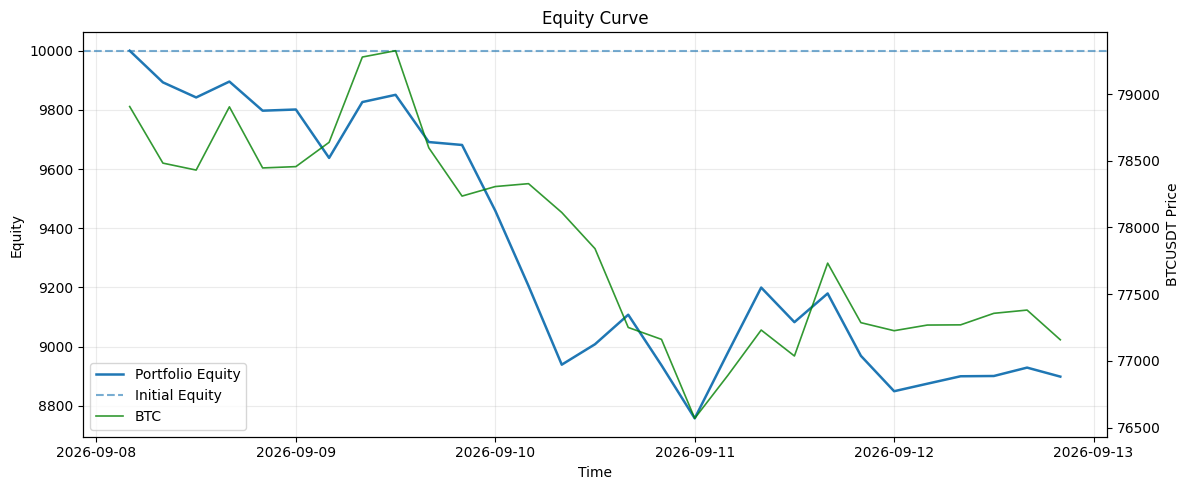

,trades,wins,win_rate_pct,avg_return_pct,total_pnl
strategy,,,,,
entry_break_max__exit_break_max,8,3,37.5,0.008064,82.035032
entry_three_green_candles__exit_three_green_candles,2,1,50.0,0.017260,69.014237
entry_conviction_pullback__exit_conviction_pullback,2,0,0.0,-0.036615,-136.672634
entry_momentum_hh_hl__exit_momentum_hh_hl,5,1,20.0,-0.036064,-336.704885
entry_break_boll_upper__exit_break_boll_upper,3,0,0.0,-0.134832,-771.776970


In [71]:
print("✓ PORTFOLIO ANALYSIS")
trade_frame = backtest_results['portfolio']["trade_frame"]

print(f"\nExit Reason Breakdown:")
exit_reasons = []
for reason in ['trailing_stop', 'time_stop', 'vol_take_profit', 'vol_take_profit_below_entry', 'vol_take_profit_below_entry_immediate', 'exit_signal', 'stop_loss', 'profit_lock_in']:
    reason_dict = {
        "reason": reason,
        "count": (trade_frame['close_reason'] == reason).sum(),
        "pct": 100 * (trade_frame['close_reason'] == reason).sum() / len(trade_frame)
        }
    
    exit_reasons.append(reason_dict)

exit_reasons.sort(key=lambda x: x["count"], reverse=True)
print(f"\nExit Reason Breakdown (sorted by count):")
for reason_dict in exit_reasons:
    print(f"   - {reason_dict['reason']}: {reason_dict['count']} ({reason_dict['pct']:.1f}%)")


import validation
validation = reload(validation)
from validation import *

plot_equity_curve(backtest_results, backtest_payload, start_date=start_date, end_date=end_date, 
                  plot_btc=True, dict_of_pairs=dict_of_pairs)

strategy_regime_stats = (
    trade_frame.assign(win=trade_frame["pnl"] > 0)
    .groupby(["strategy"])
    .agg(
        trades=("win", "size"),
        wins=("win", "sum"),
        win_rate_pct=("win", "mean"),
        avg_return_pct=("return_pct", "mean"),
        total_pnl=("pnl", "sum"),
    )
)

strategy_regime_stats["win_rate_pct"] *= 100
display(strategy_regime_stats.sort_values(["total_pnl"], ascending=[False]).head(40))

In [72]:
trade_frame

,pair,strategy,regime,entry_bar,entry_time,entry_price,quantity,initial_stop_price,stop_price,entry_value,...,pnl,return_pct,hold_bars,close_reason,open_time,close_time,profit,gross_profit,gain,holding_period
0,FETUSDT,entry_break_max__exit_break_max,neutral,0,2026-09-08 03:59:59.999,0.185900,1.075820e+04,0.176933,0.178788,2000.000000,...,-149.207330,-0.074604,10,stop_loss,2026-09-08 03:59:59.999,2026-09-09 19:59:59.999,-149.207330,-145.352682,0.925396,1 days 16:00:00
1,STRKUSDT,entry_three_green_candles__exit_three_green_ca...,weak_bull,0,2026-09-08 03:59:59.999,0.031360,6.375618e+04,0.030104,0.030146,1999.637905,...,183.008158,0.091521,10,vol_take_profit,2026-09-08 03:59:59.999,2026-09-09 19:59:59.999,183.008158,187.194629,1.091521,1 days 16:00:00
2,METISUSDT,entry_three_green_candles__exit_three_green_ca...,weak_bull,0,2026-09-08 03:59:59.999,3.140000,6.366610e+02,2.995446,3.045600,1999.874609,...,-113.993922,-0.057001,11,stop_loss,2026-09-08 03:59:59.999,2026-09-09 23:59:59.999,-113.993922,-110.104277,0.942999,1 days 20:00:00
3,LINEAUSDT,entry_momentum_hh_hl__exit_momentum_hh_hl,weak_bull,0,2026-09-08 03:59:59.999,0.002708,7.382933e+05,0.002606,0.002606,1999.722787,...,-71.588897,-0.035799,12,time_stop,2026-09-08 03:59:59.999,2026-09-10 03:59:59.999,-71.588897,-67.657108,0.964201,2 days 00:00:00
4,SENTUSDT,entry_break_max__exit_break_max,neutral,0,2026-09-08 03:59:59.999,0.015010,1.332055e+05,0.013950,0.014175,1999.989711,...,-110.289728,-0.055145,13,time_stop,2026-09-08 03:59:59.999,2026-09-10 07:59:59.999,-110.289728,-106.396144,0.944855,2 days 04:00:00
5,COTIUSDT,entry_break_boll_upper__exit_break_boll_upper,strong_bull,10,2026-09-09 19:59:59.999,0.021130,9.291292e+04,0.018096,0.020624,1963.460819,...,-282.776272,-0.144019,2,stop_loss,2026-09-09 19:59:59.999,2026-09-10 03:59:59.999,-282.776272,-279.128479,0.855981,0 days 08:00:00
6,STRKUSDT,entry_break_max__exit_break_max,neutral,10,2026-09-09 19:59:59.999,0.032100,6.116169e+04,0.030203,0.032280,1963.503439,...,-85.588697,-0.043590,2,stop_loss,2026-09-09 19:59:59.999,2026-09-10 03:59:59.999,-85.588697,-81.743434,0.956410,0 days 08:00:00
7,SCUSDT,entry_break_boll_upper__exit_break_boll_upper,neutral,11,2026-09-09 23:59:59.999,0.000963,1.963345e+06,0.000874,0.001006,1891.223972,...,-279.311056,-0.147688,2,stop_loss,2026-09-09 23:59:59.999,2026-09-10 07:59:59.999,-279.311056,-275.804412,0.852312,0 days 08:00:00
8,NEWTUSDT,entry_break_max__exit_break_max,weak_bull,12,2026-09-10 03:59:59.999,0.046450,3.959271e+04,0.041782,0.053730,1839.629711,...,358.028655,0.194620,2,vol_take_profit,2026-09-10 03:59:59.999,2026-09-10 11:59:59.999,358.028655,362.069984,1.194620,0 days 08:00:00
9,PHAUSDT,entry_conviction_pullback__exit_conviction_pul...,neutral,12,2026-09-10 03:59:59.999,0.026900,6.836672e+04,0.025802,0.027360,1839.390221,...,-45.286485,-0.024620,2,stop_loss,2026-09-10 03:59:59.999,2026-09-10 11:59:59.999,-45.286485,-41.649354,0.975380,0 days 08:00:00


In [ ]:
# === PARITY RUN: reproduce the live bot bar-for-bar ===
from dataclasses import replace

import backtest_engine
backtest_engine = reload(backtest_engine)
from backtest_engine import *

import live_parity
live_parity = reload(live_parity)
from live_parity import (
    build_parity_seed, summarize_seed, reconcile_parity,
    decision_parity, format_decision_parity,
)

# Anchor = the FIRST bar close of the window (same instant as STEP 7's start_date).
PARITY_ANCHOR = "08/09/2026 07:59:59"

parity_seed = build_parity_seed(
    PARITY_ANCHOR,
    live_db="live_runtime/live_state.sqlite",
    monitor_db="monitor/monitor.sqlite",
    trades_log="live_runtime/logs/trades.log",
    mode="LIVE",
)
print(summarize_seed(parity_seed))
print(parity_seed.diagnostics)

parity_cfg = replace(
    engine_cfg,
    start_date=PARITY_ANCHOR,       # must match the seed anchor
    end_date=pd.to_datetime(time.time(), unit="s").strftime("%d/%m/%Y %H:%M"),              # keep this at/below the last bar live processed
    ensure_parity=True,
    parity_seed=parity_seed.to_dict(),
    skip_entries_with_tp_below_close=False,
)

parity_results = run_portfolio_backtest(backtest_payload, cfg=parity_cfg,
                                        current_slippage_array=None)["portfolio"]
print(60*"-")
print(format_metrics_report(parity_results["metrics"]))
print(60*"-")
print(parity_results["parity_report"]["stats"], "\n")

print(60*"-")
print("trade frame")

display(parity_results["trade_frame"])          # includes is_open rows with NaN gain
print("still open")
display(parity_results["open_positions_frame"])

recon = reconcile_parity(parity_seed, parity_results["trade_frame"])
print("counts")
print(recon["counts"])
print(60*"-")
print("reason_mismatch")
# exit_bar_agree=True => live and engine closed the SAME bar: an intrabar live TP
# vs the engine's bar-close stamp, i.e. a timestamp-only difference.
display(recon["reason_mismatch"][["pair", "strategy", "reason", "close_reason",
                                  "exit_bar_live", "exit_bar_engine", "exit_bar_agree"]])
print(60*"-")
print("live only")
display(recon["live_only"][["pair", "strategy", "entry_time", "reason"]])
print(60*"-")
print("engine only")
display(recon["engine_only"][["pair", "strategy", "open_time", "close_reason"]])

# === DECISION PARITY: same entry bar+strategy, same exit bar+reason ===
# PRICES ARE IGNORED on purpose (slippage makes them differ, that is accepted).
# Every row that is not "same bar / same reason" is classified as either
# "shifted" (the other side traded the same pair+strategy a bar or more away)
# or "missing" (the other side never traded it) - two different bugs to chase.
decisions = decision_parity(parity_seed, parity_results["trade_frame"])
print(format_decision_parity(decisions))
print("\nentry gaps (per side; 'shifted' shows both sides)")
display(decisions["entries"][decisions["entries"]["match_class"] != "matched"])
print("exit gaps (matched positions only)")
display(decisions["exits"][decisions["exits"]["exit_class"] != "same_bar_reason_ok"])


In [ ]:
# === SWEEP: three-green-candles knobs — FULL CARTESIAN GRID (in-memory results) ===
# Every combo = re-apply the strategy -> recompile a SINGLE-STRATEGY payload ->
# rerun the engine. Only the 3-candle strategy is in the payload, so each number
# below is that strategy alone competing for the whole 5-slot book.
#
# GRID_SETS = list of passes. Each pass is a FULL grid over the knobs it names
# (values from KNOBS), with every OTHER knob held at BASELINE. Splitting the knob
# list into passes of <=4 keeps a pass at <=4^4 = 256 combos instead of one
# impossible 4^8 = 65,536 grid:
#   pass 1 : pattern_bars x spread_multiple x require_rising_gaps x trailing_stop_pct   = 128
#   pass 2 : lower_vol x upper_vol x gain_ratio x fast_profit_threshold                = 256
#
# The per-knob marginals only use the passes that actually swept that knob, so a
# knob held at BASELINE is not reported as if it were a value ("OFF" in a
# marginal means a genuine None, i.e. that gate is disabled, not "not swept").
# Because each pass is a full grid, a knob whose bucket means come out IDENTICAL
# has no effect on the objective - the cell flags that automatically.
#
# Results are NOT persisted (results_df only). For a long grid, run it in slices:
# combos are numbered in pass order, so raise SKIP_RUNS between sessions instead
# of losing work. MAX_RUNS caps a single launch (use a small one to calibrate).
#
# NOTE: lower_volatility_threshold=None switches the volatility band OFF, so
# those combos do not depend on upper_volatility_threshold (they repeat).

import gc
import itertools
import time
from dataclasses import replace

import numpy as np
import pandas as pd

import strategies
strategies = reload(strategies)
from strategies import apply_three_green_candles_strategy, STRATEGY_AUX_COLUMNS

import backtest_prep
backtest_prep = reload(backtest_prep)
from backtest_prep import build_strategy_specs, compile_backtest_payload

import backtest_engine
backtest_engine = reload(backtest_engine)
from backtest_engine import EngineConfig, run_portfolio_backtest, _build_date_mask

# ---------------------------------------------------------------- identifiers
EXECUTION_FRAME = execution_frame            # "4hourly" (set in STEP 1b)
ENTRY_COL = "entry_three_green_candles"
EXIT_COL = "exit_three_green_candles"
STRATEGY_SPECS = build_strategy_specs([ENTRY_COL], [EXIT_COL], mode="pairwise")
STRATEGY_NAME = STRATEGY_SPECS[0]["name"]    # "entry_three_green_candles__exit_three_green_candles"
GATE_COL = "structure_ok"                    # match STEP 5

if "dict_of_pairs_ori" not in globals():
    raise RuntimeError("Run STEP 2 first: the sweep needs the prepared dataset (dict_of_pairs_ori).")
# The strategy only ADDS its own entry/exit/aux columns, so applying it to the
# prepared base repeatedly is idempotent. It does mutate dict_of_pairs_ori's
# frames in place (the copy in STEP 3 is unaffected).
SWEEP_BASE = dict_of_pairs_ori

# ------------------------------------------------- the config not being swept
BASELINE = dict(
    pattern_bars=3,
    spread_multiple=4.0,
    rsi_slope_min=0.0,
    require_rising_gaps=True,
    volume_col="quote_asset_volume",
    stop_lookback_bars=3,
    stop_spread_multiple=1.25,
    fast_profit_threshold=2.0,
    lower_volatility_threshold=0.01,
    upper_volatility_threshold=0.06,
    gain_ratio=1.15,
    trailing_stop_pct=0.06,
    max_hold_bars=36,
    vol_take_profit_multiple=5.0,
    min_signal_hold_bars=6,
)

# --------------------------------------------------- 4 values for every knob
KNOBS = {
    # ---- entry conditions ----
    "pattern_bars":               [2, 3, 4, 5],
    "spread_multiple":            [2.0, 3.0, 4.0, 6.0],      # thrust bound, short spreads
    "require_rising_gaps":        [True, False],             # switch -> 2 values
    "rsi_slope_min":              [-1.0, 0.0, 0.5, 1.5],     # condition 6 threshold
    # ---- exit geometry ----
    "fast_profit_threshold":      [1.0, 2.0, 3.0, 5.0],      # builds TP = ema7_high + fpt*spread
    "stop_lookback_bars":         [2, 3, 5, 10],
    "stop_spread_multiple":       [0.75, 1.25, 2.0, 3.0],
    "trailing_stop_pct":          [0.02, 0.03, 0.06, 0.10],
    "max_hold_bars":              [6, 12, 24, 36],
    # ---- optional gates ----
    "lower_volatility_threshold": [None, 0.01, 0.02, 0.03],  # None = vol band OFF
    "upper_volatility_threshold": [0.04, 0.06, 0.08, 0.12],
    "gain_ratio":                 [None, 1.03, 1.15, 1.30],  # None = gain gate OFF
    # ---- INERT in the backtest engine: this only writes the
    # {entry_col}__vol_take_profit_threshold aux, which the engine stores on the
    # position and never compares (the TP exit is `high > take_profit_price`).
    # It only builds a TP price in apply_strategy_mr_v1. Kept for reference; do
    # not spend a grid pass on it.
    "vol_take_profit_multiple":   [3.0, 5.0, 8.0, 12.0],
}

GRID_SETS = [
    ["pattern_bars", "spread_multiple", "require_rising_gaps", "trailing_stop_pct"],
    ["lower_volatility_threshold", "upper_volatility_threshold", "gain_ratio", "fast_profit_threshold"],
]

SKIP_RUNS = 0
MAX_RUNS = None            # e.g. 8 for a smoke test / ETA calibration
OBJECTIVE = "multiple"     # "multiple" | "final_equity" | "expectancy_pct" | "win_rate"

# ------------------------------------------------------------- engine config
SWEEP_START = "01/10/2020"
SWEEP_END = "01/12/2021"
SWEEP_CASH = 5000.0

_sweep_overrides = dict(start_date=SWEEP_START, end_date=SWEEP_END, initial_cash=SWEEP_CASH)
if "engine_cfg" in globals():
    # Reuse whatever STEP 7 is running (max positions, trailing multiples,
    # min_signal_hold_bars_override, TP-skip flag, ...) and only move the window.
    SWEEP_CFG = replace(engine_cfg, **_sweep_overrides)
else:
    SWEEP_CFG = EngineConfig(**_sweep_overrides)

# ------------------------------------------------------------- plan the runs
_plans = []
for _pass_idx, _names in enumerate(GRID_SETS):
    for _combo in itertools.product(*(KNOBS[n] for n in _names)):
        _plans.append((_pass_idx, _names, _combo))

_total_planned = len(_plans)
_plans = _plans[SKIP_RUNS:]
if MAX_RUNS is not None:
    _plans = _plans[:MAX_RUNS]

print(f"passes        : {len(GRID_SETS)}  -> {_total_planned} combos in total")
for _i, _names in enumerate(GRID_SETS):
    _n = int(np.prod([len(KNOBS[k]) for k in _names]))
    print(f"  pass {_i + 1}: {' x '.join(_names)}  = {_n} combos")
print(f"this launch   : {len(_plans)} combos (skip={SKIP_RUNS}, max={MAX_RUNS})")
print(f"window        : {SWEEP_START} -> {SWEEP_END} | cash {SWEEP_CASH:,.0f} | gate {GATE_COL!r}")

# ------------------------------------------------------------------- run loop
_runs = []
_t0 = time.time()

for _i, (_pass_idx, _names, _combo) in enumerate(_plans, start=1):
    _cfg = {**BASELINE, **dict(zip(_names, _combo))}

    # 1) apply the strategy with this combo (in place; overwrites its own columns)
    apply_three_green_candles_strategy(
        dict_of_pairs=SWEEP_BASE,
        execution_frame=EXECUTION_FRAME,
        entry_col=ENTRY_COL,
        exit_col=EXIT_COL,
        aux_prefix=ENTRY_COL,
        **_cfg,
    )

    # 2) recompile the payload — only this strategy's spec is included
    _payload = compile_backtest_payload(
        dict_of_pairs=SWEEP_BASE,
        execution_frame=EXECUTION_FRAME,
        strategy_specs=STRATEGY_SPECS,
        gate_col=GATE_COL,
        time_col="close_time",
        price_columns=("open", "high", "low", "close"),
        aux_columns=STRATEGY_AUX_COLUMNS,
        context_columns=["regime"],
        enforce_bar_cadence=False,
        min_spacing_ratio=0.9,
    )

    # 3) run the engine on the sweep window
    _result = run_portfolio_backtest(_payload, cfg=SWEEP_CFG, current_slippage_array=None)["portfolio"]
    _metrics = _result["metrics"]

    # payload["strategies"][name]["entry"] is already gate-ANDed by the compiler
    _mask = _build_date_mask(pd.to_datetime(_payload["timeline"]), SWEEP_START, SWEEP_END)
    _gated_signals = int(_payload["strategies"][STRATEGY_NAME]["entry"][_mask].sum())

    _runs.append(
        {
            "run": len(_runs) + SKIP_RUNS + 1,
            "pass": _pass_idx + 1,
            **dict(zip(_names, _combo)),
            "vol_band_on": _cfg["lower_volatility_threshold"] is not None,
            "gated_signals": _gated_signals,
            "trades": _metrics.get("trade_count"),
            "multiple": _metrics.get("total_profit_multiple"),
            "final_equity": _metrics.get("final_equity"),
            "net_return_pct": _metrics.get("net_return_pct"),
            "win_rate": _metrics.get("win_rate"),
            "expectancy_pct": _metrics.get("expectancy_pct"),
            "max_dd_pct": _metrics.get("max_drawdown_pct"),
            "avg_hold_bars": _metrics.get("avg_hold_bars"),
            "secs": round(time.time() - _t0, 1),
        }
    )

    del _payload, _result, _metrics
    gc.collect()

    _elapsed = time.time() - _t0
    _eta = _elapsed / _i * (len(_plans) - _i)
    _label = " ".join(f"{k}={v}" for k, v in zip(_names, _combo))
    print(
        f"[{_i}/{len(_plans)}] pass{_pass_idx + 1} {_label} -> "
        f"signals={_gated_signals} trades={_runs[-1]['trades']} "
        f"multiple={_runs[-1]['multiple']} dd={_runs[-1]['max_dd_pct']}% "
        f"| elapsed {_elapsed / 60:.1f}m eta {_eta / 60:.1f}m"
    )

results_df = pd.DataFrame(_runs)

# ------------------------------------------------------------------- reporting
if results_df.empty:
    print("no runs executed")
else:
    _cols = ["run", "pass", "gated_signals", "trades", "multiple", "final_equity",
             "net_return_pct", "win_rate", "expectancy_pct", "max_dd_pct", "avg_hold_bars", "secs"]
    _cols += [n for n in KNOBS if n in results_df.columns]
    display(results_df.sort_values(OBJECTIVE, ascending=False, na_position="last")[_cols])

    print(f"\nbest by {OBJECTIVE}:")
    _best = results_df.dropna(subset=[OBJECTIVE]).sort_values(OBJECTIVE, ascending=False).head(1)
    if not _best.empty:
        _row = _best.iloc[0]
        _best_cfg = {**BASELINE, **{k: _row[k] for k in KNOBS if k in results_df.columns}}
        print("  " + ", ".join(f"{k}={v}" for k, v in _best_cfg.items()))
        print(f"  -> multiple={_row['multiple']} trades={_row['trades']} "
              f"win_rate={_row['win_rate']}% dd={_row['max_dd_pct']}%")

    print("\nper-knob effect (only the passes that swept the knob; 'OFF' = that gate disabled):")
    for _knob in KNOBS:
        _knob_passes = [i + 1 for i, _names in enumerate(GRID_SETS) if _knob in _names]
        if not _knob_passes or _knob not in results_df.columns:
            continue
        _sub = results_df[results_df["pass"].isin(_knob_passes)]
        if _sub.empty:
            continue
        _keys = _sub[_knob].astype(object).where(_sub[_knob].notna(), "OFF")
        _grp = (
            _sub.assign(_key=_keys)
            .groupby("_key", dropna=False)
            .agg(runs=(OBJECTIVE, "size"), mean_obj=(OBJECTIVE, "mean"),
                 best_obj=(OBJECTIVE, "max"), med_signals=("gated_signals", "median"),
                 med_trades=("trades", "median"))
            .sort_values("mean_obj", ascending=False)
        )
        _lo, _hi = np.nanmin(_grp["mean_obj"].to_numpy(dtype=float)), np.nanmax(_grp["mean_obj"].to_numpy(dtype=float))
        _flag = "   <-- NO EFFECT on the objective" if (_hi - _lo) == 0 else ""
        print(f"\n  --- {_knob} (others at BASELINE){_flag} ---")
        display(_grp.round(3))

    print(f"\ntotal wall time: {(time.time() - _t0) / 60:.1f} min")


passes        : 2  -> 384 combos in total
  pass 1: pattern_bars x spread_multiple x require_rising_gaps x trailing_stop_pct  = 128 combos
  pass 2: lower_volatility_threshold x upper_volatility_threshold x gain_ratio x vol_take_profit_multiple  = 256 combos
this launch   : 384 combos (skip=0, max=None)
window        : 01/10/2020 -> 01/12/2021 | cash 10,000 | gate 'structure_ok'
[1/384] pass1 pattern_bars=2 spread_multiple=2.0 require_rising_gaps=True trailing_stop_pct=0.02 -> signals=3824 trades=1600 multiple=14.1824 dd=-32.97% | elapsed 0.2m eta 92.8m
[2/384] pass1 pattern_bars=2 spread_multiple=2.0 require_rising_gaps=True trailing_stop_pct=0.03 -> signals=3824 trades=1437 multiple=20.4516 dd=-36.11% | elapsed 0.5m eta 92.6m
[3/384] pass1 pattern_bars=2 spread_multiple=2.0 require_rising_gaps=True trailing_stop_pct=0.06 -> signals=3824 trades=1142 multiple=20.13 dd=-33.04% | elapsed 0.7m eta 91.9m
[4/384] pass1 pattern_bars=2 spread_multiple=2.0 require_rising_gaps=True trailing_sto

,run,pass,gated_signals,trades,multiple,final_equity,net_return_pct,win_rate,expectancy_pct,max_dd_pct,avg_hold_bars,secs,pattern_bars,spread_multiple,require_rising_gaps,trailing_stop_pct,vol_take_profit_multiple,lower_volatility_threshold,upper_volatility_threshold,gain_ratio
14,15,1,6630,1436,53.9059,539059.15,5290.59,49.58,1.45,-42.44,5.6,216.0,2.0,3.0,False,0.06,NaN,NaN,NaN,NaN
30,31,1,6894,1441,48.3356,483356.33,4733.56,49.41,1.41,-42.44,5.6,446.8,2.0,6.0,False,0.06,NaN,NaN,NaN,NaN
22,23,1,6790,1441,48.3356,483356.33,4733.56,49.41,1.41,-42.44,5.6,332.0,2.0,4.0,False,0.06,NaN,NaN,NaN,NaN
6,7,1,6170,1383,39.8373,398373.04,3883.73,48.59,1.40,-42.42,5.7,100.5,2.0,2.0,False,0.06,NaN,NaN,NaN,NaN
9,10,1,4259,1512,35.3351,353351.11,3433.51,43.85,1.20,-29.89,4.2,144.4,2.0,3.0,True,0.03,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,101,1,20,19,1.0335,10335.35,3.35,42.11,0.81,-3.39,2.7,1465.4,5.0,2.0,False,0.02,NaN,NaN,NaN,NaN
105,106,1,25,24,1.0290,10290.45,2.90,41.67,0.54,-6.83,3.1,1537.8,5.0,3.0,True,0.03,NaN,NaN,NaN,NaN
101,102,1,20,19,1.0276,10275.50,2.76,42.11,0.66,-4.03,3.8,1479.9,5.0,2.0,False,0.03,NaN,NaN,NaN,NaN
96,97,1,12,12,1.0081,10080.53,0.81,33.33,0.28,-3.39,3.1,1407.0,5.0,2.0,True,0.02,NaN,NaN,NaN,NaN



best by multiple:
  pattern_bars=2.0, spread_multiple=3.0, rsi_slope_min=0.0, require_rising_gaps=False, volume_col=quote_asset_volume, stop_lookback_bars=3, stop_spread_multiple=1.25, fast_profit_threshold=2.0, lower_volatility_threshold=nan, upper_volatility_threshold=nan, gain_ratio=nan, trailing_stop_pct=0.06, max_hold_bars=36, vol_take_profit_multiple=nan, min_signal_hold_bars=6
  -> multiple=53.9059 trades=1436 win_rate=49.58% dd=-42.44%

per-knob effect (mean / best of the objective within this launch):

  --- pattern_bars (others at BASELINE) ---


,runs,mean_mult,best_mult,med_signals,med_trades
_key,,,,,
2.0,32,29.376,53.906,5341.5,1441.0
3.0,32,9.500,24.852,1244.0,751.5
OFF,256,5.646,8.676,1196.0,694.0
4.0,32,1.758,2.394,212.0,175.0
5.0,32,1.159,1.407,38.0,30.5



  --- spread_multiple (others at BASELINE) ---


...


  --- upper_volatility_threshold (others at BASELINE) ---


,runs,mean_mult,best_mult,med_signals,med_trades
_key,,,,,
OFF,128,10.448,53.906,592.5,404.0
0.12,64,7.316,8.676,1294.5,735.5
0.08,64,6.183,8.272,1267.5,724.5
0.06,64,5.833,8.272,1103.5,658.5
0.04,64,3.253,8.272,583.0,354.5



  --- gain_ratio (others at BASELINE) ---


,runs,mean_mult,best_mult,med_signals,med_trades
_key,,,,,
OFF,192,9.096,53.906,1212.0,699.0
1.15,64,6.503,8.504,1211.5,707.5
1.03,64,6.374,8.676,1391.5,737.0
1.3,64,3.315,4.520,648.0,471.0



total wall time: 92.8 min


In [110]:
# === Month-on-month state from the portfolio curves ===
# backtest_results["portfolio"] exposes per-4h-bar series over the date-masked
# backtest window (the same mask the engine uses): equity_curve, cash_curve,
# open_positions_curve, closed_trades_curve. Resample each to month-end.
# NOTE: requires the STEP 7 engine cell to have been re-run so the portfolio
# result includes cash_curve / closed_trades_curve (added 2026-09-05).
#
# start_date / end_date may be "DD/MM/YYYY" or "DD/MM/YYYY HH:MM"; the window is
# rebuilt with the engine's own parser so the curve indices line up with the
# (already filtered) equity/cash/closed-trade arrays.

from backtest_engine import _build_date_mask

_timeline = pd.to_datetime(backtest_payload["timeline"])
_mask = _build_date_mask(_timeline, start_date, end_date)

_portfolio = backtest_results["portfolio"]
_monthly_equity = (
    pd.Series(_portfolio["equity_curve"], index=_timeline[_mask]).dropna().resample("ME").last()
)
_monthly_cash = (
    pd.Series(_portfolio["cash_curve"], index=_timeline[_mask]).dropna().resample("ME").last()
)
_monthly_closed = (
    pd.Series(_portfolio["closed_trades_curve"], index=_timeline[_mask]).dropna().resample("ME").last()
)
_monthly_returns = _monthly_equity.pct_change().dropna()


def _money(value):
    return f"{value:,.0f}" if pd.notna(value) else value


def _pct(value):
    return f"{value * 100:+.0f}%" if pd.notna(value) else value


def _count(value):
    return f"{value:,.0f}" if pd.notna(value) else value


display(pd.DataFrame({
    "equity": _monthly_equity.map(_money),
    "monthly_return_pct": _monthly_returns.map(_pct),
    "cash on hand": _monthly_cash.map(_money),
    "total closed trades": _monthly_closed.map(_count),
}))


,equity,monthly_return_pct,cash on hand,total closed trades
close_time,,,,
2026-09-30,"4,662",NaN,"3,792",3


In [111]:
backtest_results['portfolio']['open_positions_curve']

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1])

In [112]:
trade_frame.head(30)

,pair,strategy,regime,entry_bar,entry_time,entry_price,quantity,initial_stop_price,stop_price,entry_value,...,pnl,return_pct,hold_bars,close_reason,open_time,close_time,profit,gross_profit,gain,holding_period
0,QKCUSDT,entry_break_max__exit_break_max,weak_bull,0,2026-09-08 03:59:59.999,0.002831,351122.607131,0.002176,0.002176,994.800000,...,-109.802332,-0.110376,1,vol_take_profit_below_entry,2026-09-08 03:59:59.999,2026-09-08 07:59:59.999,-109.802332,-107.920652,0.889624,0 days 04:00:00
1,GUSDT,entry_break_boll_upper__exit_break_boll_upper,neutral,2,2026-09-08 11:59:59.999,0.004650,209231.930945,0.004015,0.004606,973.038494,...,-142.194594,-0.146135,2,stop_loss,2026-09-08 11:59:59.999,2026-09-08 19:59:59.999,-142.194594,-140.388906,0.853865,0 days 08:00:00
2,IOSTUSDT,entry_break_boll_upper__exit_break_boll_upper,strong_bull,9,2026-09-09 15:59:59.999,0.001729,421873.775333,0.001169,0.001169,729.452971,...,15.718085,0.021548,1,vol_take_profit,2026-09-09 15:59:59.999,2026-09-09 19:59:59.999,15.718085,17.194186,1.021548,0 days 04:00:00
3,IOSTUSDT,entry_break_max__exit_break_max,strong_bull,10,2026-09-09 19:59:59.999,0.002056,461109.067856,0.001658,0.001658,948.083690,...,-80.283557,-0.084680,1,vol_take_profit_below_entry,2026-09-09 19:59:59.999,2026-09-09 23:59:59.999,-80.283557,-78.465855,0.915320,0 days 04:00:00


In [11]:
# === ENTRY ATTRIBUTION ANALYSIS (Phase A) ===
# One row per entry that passed the current gates, labelled by its forward path
# (MFE/MAE/return at 3/6/12/24/48 bars), plus exit-route attribution from the
# trades actually taken. Backtest-only analysis: reads the compiled payload +
# trade_frame, never modifies trading logic.

# import entry_analysis
# entry_analysis = reload(entry_analysis)
# from entry_analysis import *

# entry_analysis_df = build_entry_analysis_dataset(
#     backtest_payload,
#     # start_date=start_date,
#     # end_date=end_date,
#     trade_frame=backtest_results["portfolio"]["trade_frame"],
# )

# print(f"✓ Entry analysis dataset: {len(entry_analysis_df)} gated entries")
# entry_analysis_report_dict = entry_analysis_report(entry_analysis_df)

✓ Entry analysis dataset: 48043 gated entries


In [ ]:
# trade_frame[trade_frame["close_reason"] == "vol_take_profit"]["hold_bars"].agg(["mean", "median", "min", "max"])

In [ ]:

# viability_summary = get_viable_entries_summary(backtest_payload, start_date=start_date, end_date=end_date)

# viability_summary

In [367]:
# sorted_trades  = sorted(backtest_results["portfolio"]["trades"], key = lambda x: -(x.exit_price/x.entry_price))
# # # # trade_dict = sorted_trades[40].__dict__

# for trade in sorted_trades[-10:]:

#     plot_trade_mpf(trade.__dict__, dict_of_pairs)

In [48]:
pair = "BTCUSDT"
frame_df = dict_of_pairs[pair]["dict_of_frames"][execution_frame].copy()

frame_df.iloc[[0,-1]]["open_time"]

0       2017-08-17 04:00:00
19784   2026-09-02 12:00:00
Name: open_time, dtype: datetime64[ns]

In [181]:
pair = "BTCUSDT"
frame_df = dict_of_pairs_ori[pair]["dict_of_frames"][execution_frame].copy()
frame_df["allowed_to_trade"].value_counts()
# frame_df[[col for col in frame_df.columns if "reward" in col]].tail(15)

allowed_to_trade
False    15075
True      4710
Name: count, dtype: int64

In [ ]:
# === MONITOR DATA + DIAGNOSTICS ===
# Imports live-bot telemetry (monitor/monitor.sqlite) and prints the health /
# cloud-sizing diagnostics via monitor.report.print_report — same body as
# `python monitor/report.py`. DB is opened read-only (WAL lets readers in while
# the bot is writing). The report window is anchored to the newest telemetry so
# a stopped bot still shows its last full run. A loop-heartbeat freshness check
# (not covered by print_report) is appended on top.

import importlib
import sqlite3
from datetime import timedelta
from pathlib import Path

import pandas as pd

import monitor.report as mreport
mreport = importlib.reload(mreport)

MONITOR_DB = Path("monitor/monitor.sqlite")
WINDOW_DAYS = 1          # look-back window for the diagnostics report

if not MONITOR_DB.exists():
    print(f"monitor DB not found: {MONITOR_DB.resolve()}")
    print("-> run the bot with the monitor on (LIVE_MONITOR=1) to collect telemetry.")
else:
    conn = sqlite3.connect(f"file:{MONITOR_DB}?mode=ro", uri=True)
    try:
        # ---- data availability across timestamped tables -------------------
        span = pd.read_sql_query(
            """SELECT 'cycles' AS tbl, MIN(ts) first_ts, MAX(ts) last_ts FROM cycles
               UNION ALL SELECT 'process_minute', MIN(ts), MAX(ts) FROM process_minute
               UNION ALL SELECT 'api_requests',   MIN(ts), MAX(ts) FROM api_requests""",
            conn,
        )
        first_ts = pd.to_datetime(span["first_ts"].dropna().min(), utc=True)
        last_ts  = pd.to_datetime(span["last_ts"].dropna().max(),  utc=True)
        if pd.isna(last_ts):
            print("monitor DB has no telemetry yet — is the bot running with LIVE_MONITOR=1?")
        else:
            # Anchor window to newest sample so a stopped bot reports its last
            # full run instead of an empty 'now'-anchored window.
            end   = last_ts + timedelta(minutes=1)
            start = end - timedelta(days=WINDOW_DAYS)
            print(f"telemetry span : {first_ts:%Y-%m-%d %H:%M} -> {last_ts:%Y-%m-%d %H:%M} UTC  "
                  f"(reporting last {WINDOW_DAYS}d)")
            mreport.print_report(conn, start, end)

            # ---- loop heartbeat freshness (not in print_report) ------------
            hb = pd.read_sql_query(
                "SELECT loop, last_ts, count, errors FROM loop_heartbeat", conn)
            if not hb.empty:
                print("\n[loop heartbeat]")
                for _, r in hb.iterrows():
                    last = pd.to_datetime(r["last_ts"], utc=True)
                    age  = (pd.Timestamp.now(tz="UTC") - last).total_seconds() / 60
                    print(f"  {r['loop']:12s} last={last:%Y-%m-%d %H:%M:%S} UTC  "
                          f"age={age:7.1f} min  runs={int(r['count']):>8,}  errors={int(r['errors']):,}")
    finally:
        conn.close()

In [ ]:
"""
make post-break test strategy
make previous-to-previous-high test strategy
tune green candle strategy
confirm parity between backtest and live by including rejected orders, overrides, open positions
"""

In [14]:
frame_df["ema25_tested"].value_counts()

ema25_tested
0    18524
1     1297
Name: count, dtype: int64

In [ ]:
talib.EMA(frame_df["close"], 200)

19,843 bars  17/08/2017 07:59 -> 12/09/2026 07:59

QUERY 01/07/2026 -> 20/08/2026  |  306 bars (01/07/2026 03:59 ... 20/08/2026 23:59)
POOL  2432 candidate windows inside 01/10/2020 -> 31/12/2021
--------------------------------------------------------------------------------------------------------
feature z-profile of the query vs the pool (largest |z| first):
   kurt             query=       16.77  pool=       3.906 +/- 2.081       z=+6.18
   skew             query=       2.374  pool=     -0.1441 +/- 0.5416      z=+4.65
   range_pct        query=       0.957  pool=       2.712 +/- 0.6648      z=-2.64
   down_vol_ann     query=       18.19  pool=       59.02 +/- 15.54       z=-2.63
   vol_ann          query=       33.72  pool=       82.56 +/- 19.8        z=-2.47
   spread_pct       query=       1.007  pool=       2.657 +/- 0.6997      z=-2.36
   taker_buy_share  query=      0.5007  pool=      0.4928 +/- 0.003817    z=+2.06
   max_dd           query=    -0.06219  pool=     -0.2486 +/-

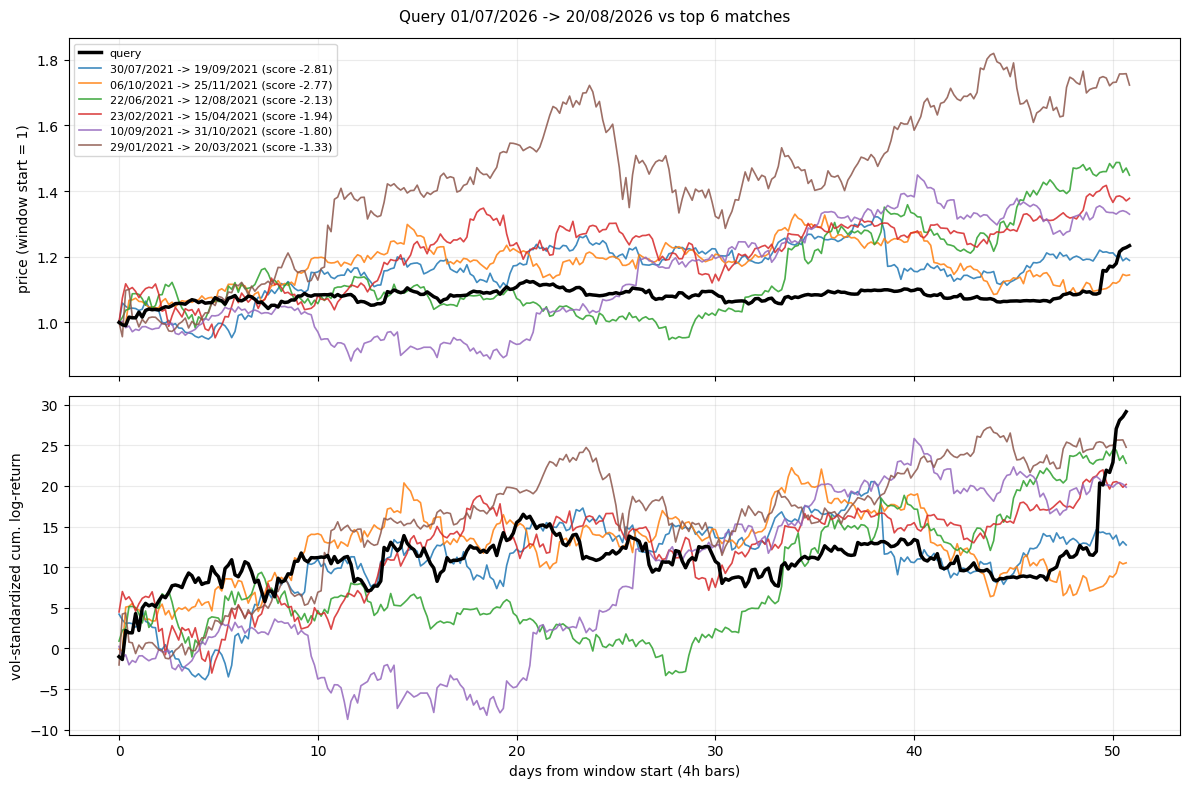


QUERY 20/08/2026 -> 12/09/2026  |  140 bars (20/08/2026 03:59 ... 12/09/2026 07:59)
POOL  2598 candidate windows inside 01/10/2020 -> 31/12/2021
--------------------------------------------------------------------------------------------------------
feature z-profile of the query vs the pool (largest |z| first):
   autocorr1        query=      0.1058  pool=     -0.0628 +/- 0.07396     z=+2.28
   down_vol_ann     query=       20.34  pool=       55.96 +/- 18.94       z=-1.88
   skew             query=       1.368  pool=     -0.1281 +/- 0.8281      z=+1.81
   vol_ann          query=       37.68  pool=        80.1 +/- 23.59       z=-1.80
   range_pct        query=       1.224  pool=       2.668 +/- 0.8136      z=-1.77
   spread_pct       query=       1.121  pool=       2.609 +/- 0.8604      z=-1.73
   half_drift_z     query=     -0.2571  pool=   -0.001933 +/- 0.1482      z=-1.72
   max_dd           query=    -0.06344  pool=     -0.1742 +/- 0.08346     z=+1.33
   vol_trend        query=   

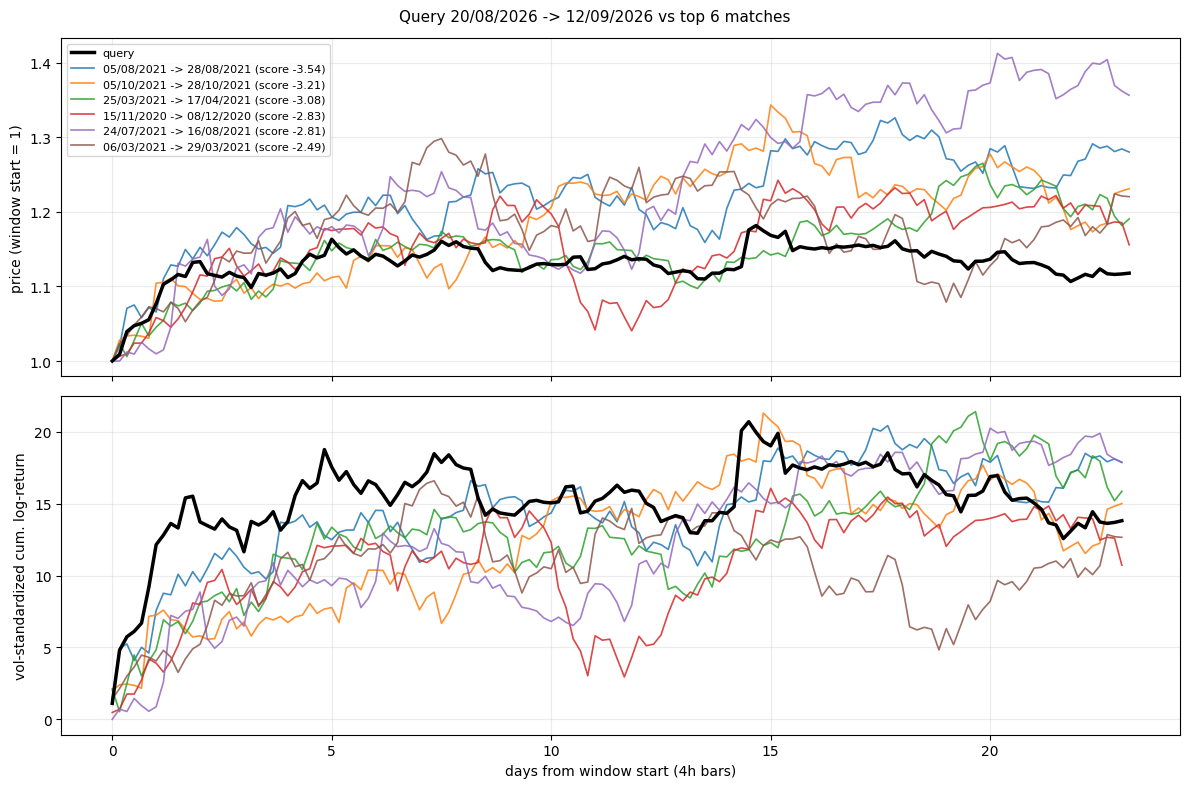

In [81]:
# === REGIME MATCHING: which parts of 10/2020-12/2021 match the 2026 windows? ===
# Analog finder (regime_matching.py): slides a window of the QUERY's own length
# across the search era; each window gets a regime feature vector (drift/vol/
# skew/kurt/autocorr/efficiency/drawdowns/range%/spread%/ema structure/taker
# share/volume trend) + a vol-standardized cumulative-return "shape" path.
# Distances are z-scored across the candidate pool and combined (lower = closer).
# Read-only; dates are DD/MM/YYYY with the engine's own day semantics.

import regime_matching
regime_matching = reload(regime_matching)
from regime_matching import (load_market_series, find_matches, select_top,
                             format_report, plot_matches, matches_to_engine_windows)

import matplotlib.pyplot as plt

# data/halal covers 2017 -> now (validation only starts 11/2025), so it is the
# only dataset where the 2026 queries and the 2020-21 search range coexist.
series = load_market_series()          # BTCUSDT 4h from data/halal/raw
print(f"{len(series):,} bars  {series['close_time'].iloc[0]:%d/%m/%Y %H:%M} -> "
      f"{series['close_time'].iloc[-1]:%d/%m/%Y %H:%M}")

QUERY_WINDOWS = {
    "A  01/07/2026 -> 20/08/2026": ("01/07/2026", "20/08/2026"),
    "B  20/08/2026 -> 12/09/2026": ("20/08/2026", "12/09/2026"),
}
SEARCH_START, SEARCH_END = "01/10/2020", "31/12/2021"   # "01/12/2021" = sweep window

match_results = {}
for label, (q_start, q_end) in QUERY_WINDOWS.items():
    # shape-only variant: find_matches(..., feature_weight=0.0) ignores the
    # amplitude features and matches the standardized path alone.
    res = find_matches(series, q_start, q_end,
                       search_start=SEARCH_START, search_end=SEARCH_END)
    top = select_top(res["candidates"], k=8)
    match_results[label] = res
    print()
    print(format_report(res, top))
    print("top matches as engine windows (EngineConfig.start_date/end_date):")
    for window in matches_to_engine_windows(top):
        print(f"   {window[0]}  ->  {window[1]}")
    plot_matches(res, top, n=6)
    plt.show()
